In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Qualitative vs Quantitative Variables (Distribution Graphs)

## Qualitative Variables (Categorical Data)

A **qualitative variable** represents **categories or labels**. It describes the quality or type of something rather than a numerical value.

### Characteristics
- Represents categories or groups.
- Cannot be measured numerically.
- Arithmetic operations (addition, subtraction, etc.) cannot be performed.

### Examples
- Gender (Male, Female)
- Blood Group (A, B, AB, O)
- City
- Department
- Hair Color

## Quantitative Variables (Numerical Data)

A **quantitative variable** represents **numerical values**. It measures a quantity and can be used in mathematical calculations.

### Characteristics
- Represents numbers.
- Can be measured or counted.
- Arithmetic operations can be performed.

### Examples
- Age
- Height
- Weight
- Salary
- Marks
- Number of Students

### Distribution Plots are made for quantitative data
#### Some plot types are as follows 
    Distplot/Histplot
    Joint Plot
    Pair Plot
    Rug Plot

In [5]:
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
df['size'].unique() 
# this means its a qualitative variable

array([2, 3, 4, 1, 6, 5])

    Histogram is a type of graph that is the best for showing distribution graphs. Its mostly used in stats

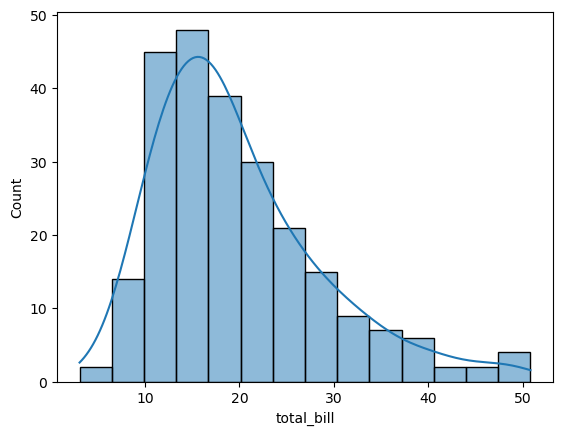

In [8]:
sns.histplot(data=df, x='total_bill',kde=True)
plt.show()
# by using histogram we create curnel density estimater curve and this curve is also known as bell curve which is made when the distribution is normal we will see things in stats

<Axes: xlabel='tip', ylabel='Count'>

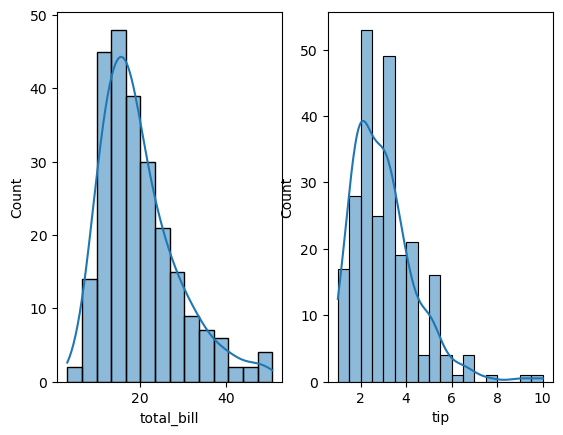

In [13]:
plt.subplot(1,2,1)
sns.histplot(data=df, x='total_bill',kde=True)
plt.subplot(1,2,2)
sns.histplot(data=df, x='tip',kde=True)


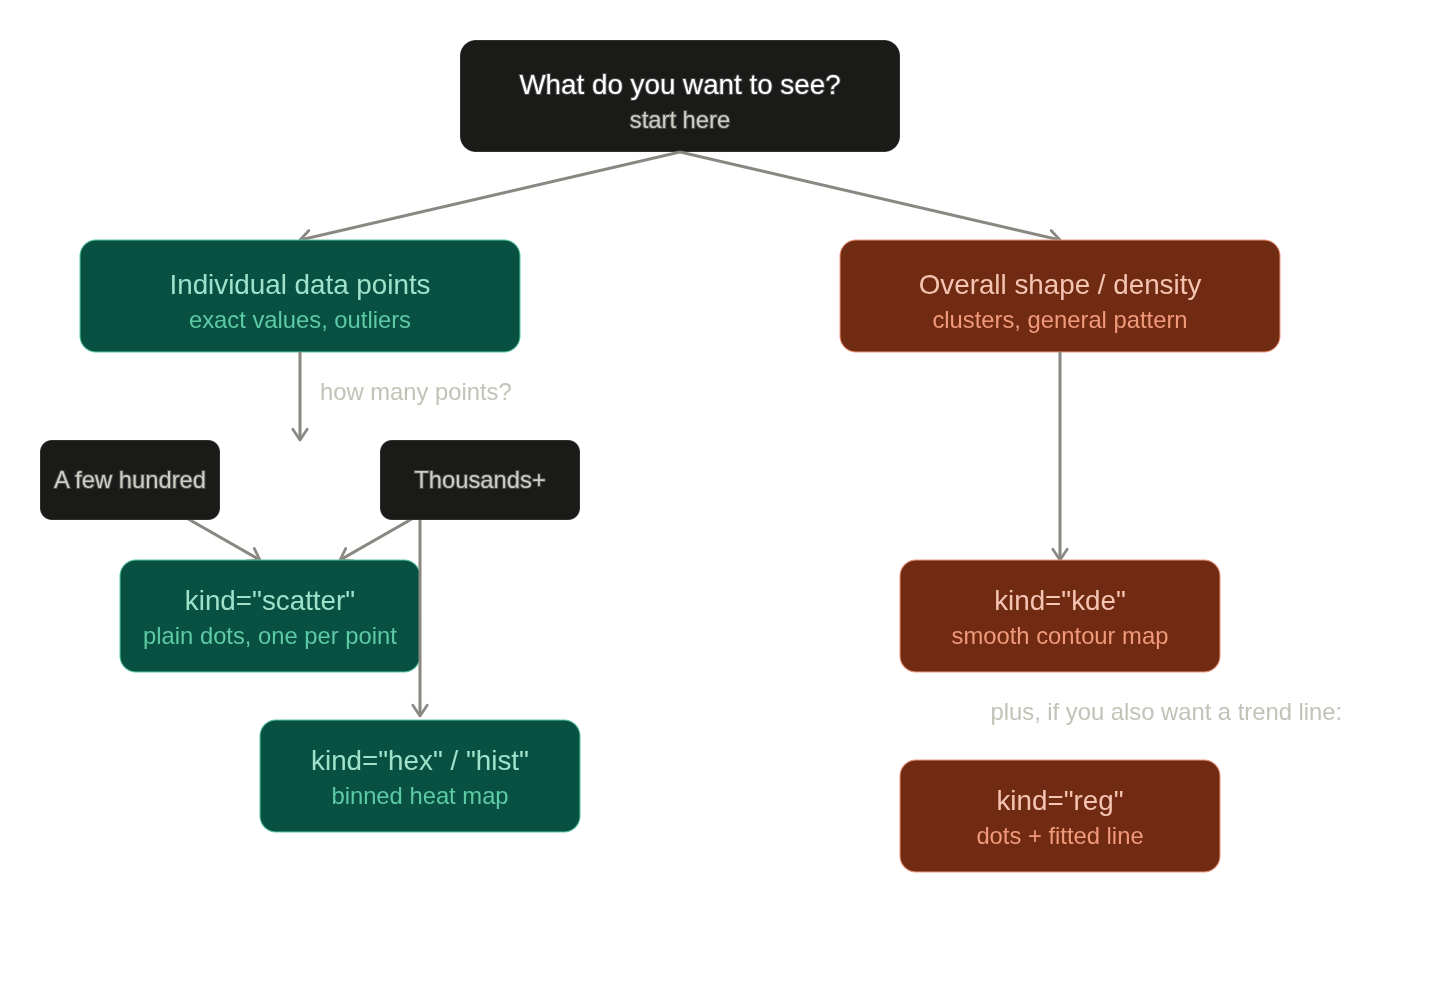

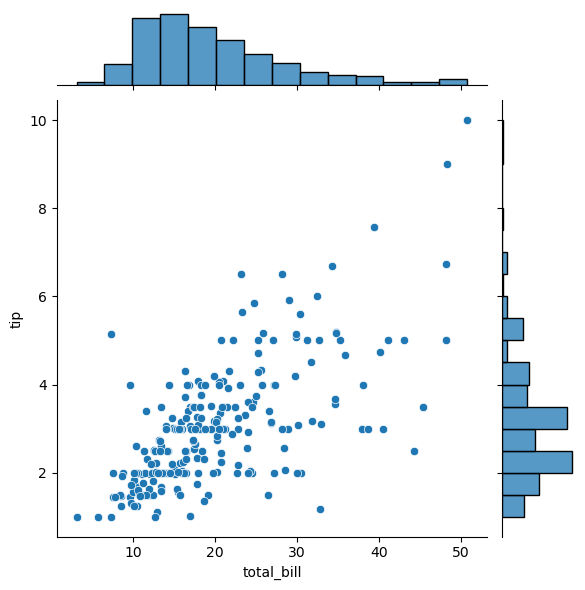

In [14]:
# in the above cell we created seprate histograms for each data now we r going to discuss what basically joint plot is 
sns.jointplot(data=df,x='total_bill',y='tip',kind='scatter')

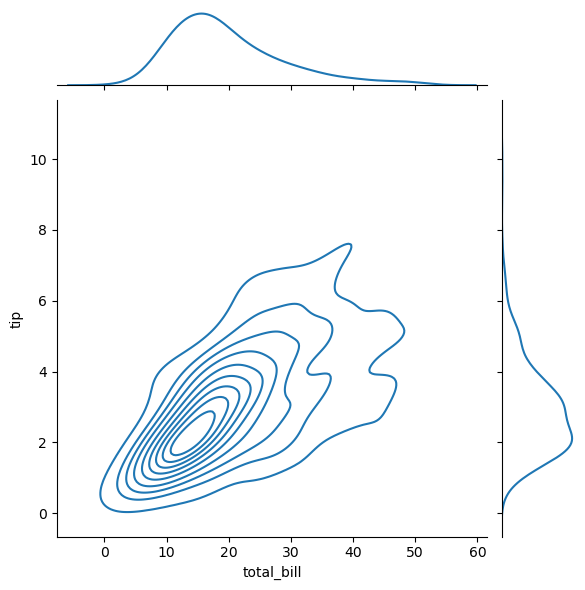

In [ ]:
sns.jointplot(data=df,x='total_bill',y='tip',kind='kde')

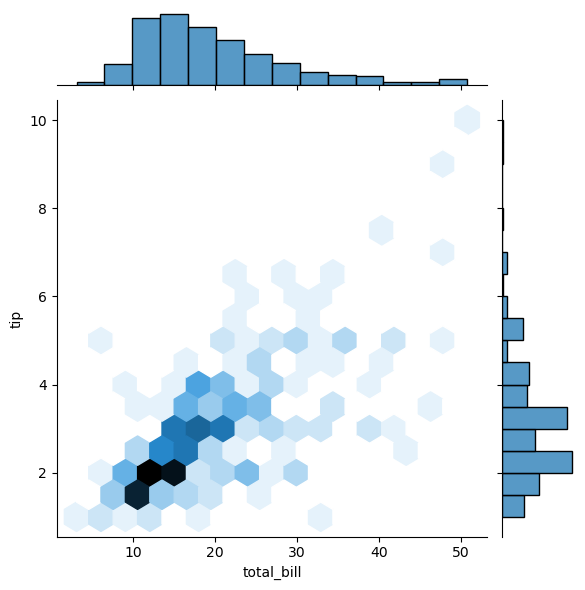

In [16]:
sns.jointplot(data=df,x='total_bill',y='tip',kind='hex')

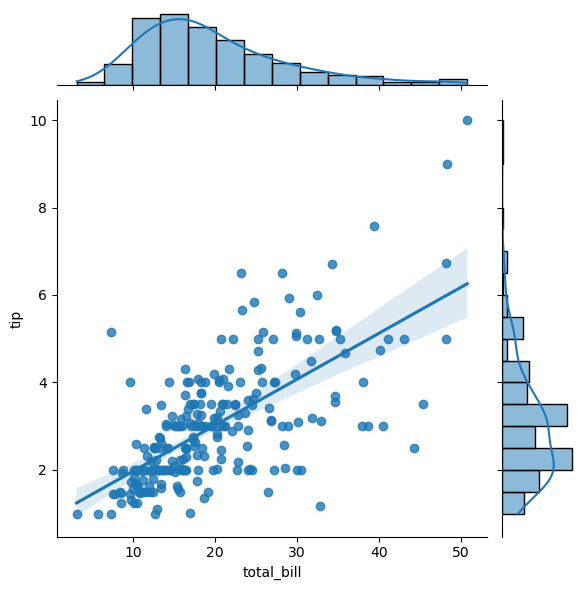

In [18]:
sns.jointplot(data=df,x='total_bill',y='tip',kind='reg')

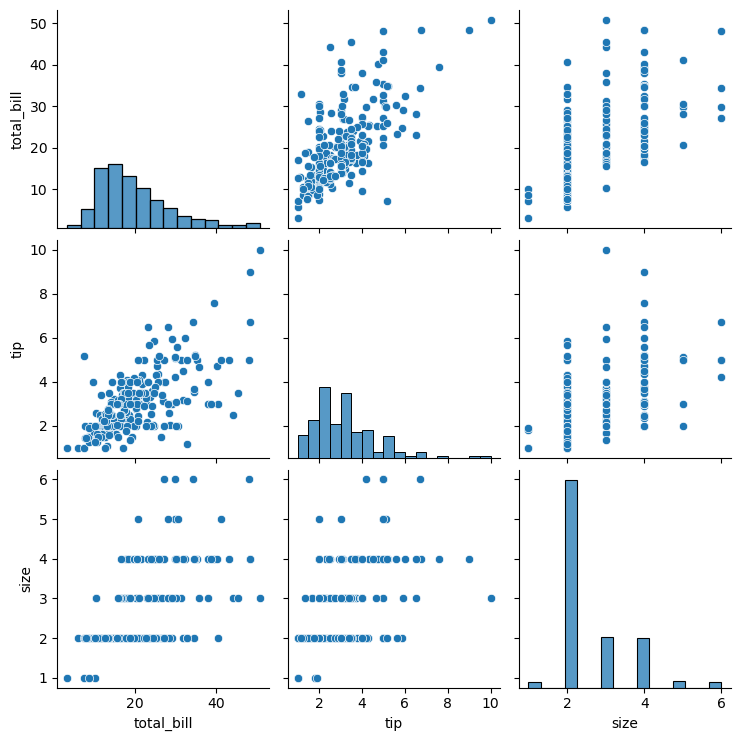

In [19]:
# pairploy
sns.pairplot(df)

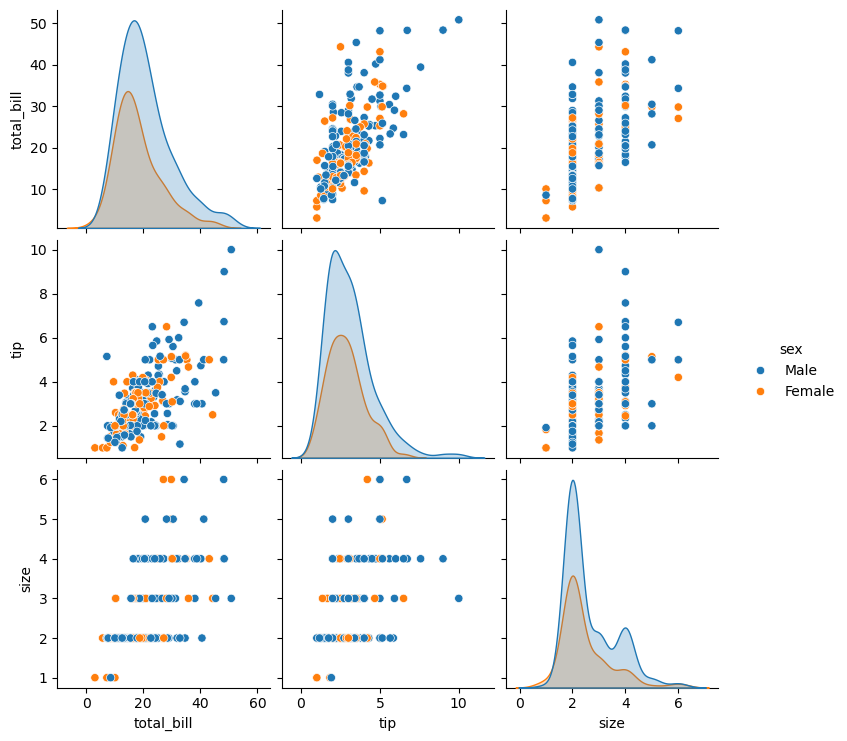

In [20]:
sns.pairplot(df,hue='sex')

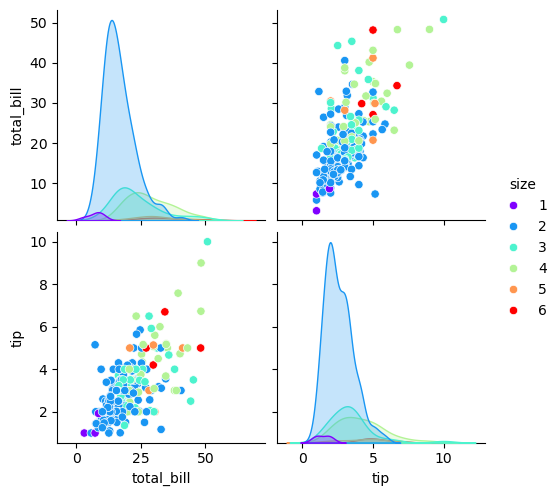

In [21]:
sns.pairplot(df,hue='size',palette='rainbow')

# Seaborn distribution plots — reference notes

Quick reference for `histplot`, `kdeplot`, `jointplot`, and `pairplot`. Written to pair with code in a notebook, not as a standalone tutorial.

---

## 1. Histogram — `sns.histplot()`

Shows how one numeric column is distributed by splitting its range into **bins** (buckets) and counting how many values fall in each.

```python
sns.histplot(data=df, x='total_bill', bins=20)
```

- **`bins`** — number of buckets. Too few = loses detail. Too many = noisy, spiky.
- Try a few different `bins` values on the same column to see how the shape changes.

---

## 2. KDE — Kernel Density Estimate

A **smoothed version of a histogram**. Instead of chunky bars with hard edges, KDE:

1. Places a small smooth "bump" (kernel) centered on every individual data point
2. Adds all the bumps together into one continuous curve
3. Where points cluster, bumps overlap and stack → curve rises
4. Where points are sparse → curve stays low

No bins involved, so it isn't affected by where bin edges happen to fall.

```python
sns.kdeplot(data=df, x='total_bill')

# Histogram + KDE overlaid together
sns.histplot(data=df, x='total_bill', kde=True)
```

**`bw_adjust`** — controls how wide each bump is (KDE's version of bin width):
- Low value (e.g. `0.2`) → jagged curve, hugs every wiggle (overfits)
- High value (e.g. `2`) → oversmoothed, can hide real structure like two separate peaks

```python
sns.kdeplot(data=df, x='total_bill', bw_adjust=0.3)  # spiky
sns.kdeplot(data=df, x='total_bill', bw_adjust=2)     # oversmoothed
```

**Right-skewed distribution** — most values bunched low, with a long tail stretching toward high values (e.g. `total_bill`, `tip`). Mean gets pulled higher than the median by the tail.

---

## 3. Jointplot — `sns.jointplot()`

Two variables, one figure:
- **Center panel** — relationship between the two variables
- **Top margin** — histogram/KDE of the x variable alone
- **Right margin** — histogram/KDE of the y variable alone

```python
sns.jointplot(data=df, x='total_bill', y='tip', kind='scatter')
```

### Choosing `kind=`

Decision comes down to two questions:

**1. Do I want individual points, or just the overall pattern?**
- Individual points → go to question 2
- Overall pattern only → `kind='kde'` (smooth contour map, no dots — good for spotting clusters)

**2. If individual points — how many do I have?**
- Few (hundreds) → `kind='scatter'` — one dot per row, good for spotting outliers
- Many (thousands) → `kind='hex'` or `kind='hist'` — dots would overlap into a blur, so instead the space is divided into tiles (hexagon or square) shaded by how many points landed there. No real difference in meaning between hex/hist, just tile shape.

**Want a trend line too?**
- `kind='reg'` — same as scatter, plus a fitted straight line and a shaded confidence band, for checking "does y increase when x increases."

| kind | center shows | best for |
|---|---|---|
| `scatter` | raw dots | small/medium data, spotting outliers |
| `hex` | hexagon density tiles | large data, avoids overlap |
| `hist` | square density tiles | large data, same as hex, different shape |
| `kde` | smooth contour lines | seeing overall shape / clusters, no dots |
| `reg` | dots + trend line | checking for a linear relationship |

---

## 4. Pairplot — `sns.pairplot()`

"Every jointplot at once." Give it a dataframe, it builds a **grid**: every numeric column vs every other numeric column.

```python
sns.pairplot(df)

# color points by a category
sns.pairplot(df, hue='sex')
```

### The one rule for reading any cell

For a cell at a given **row** and **column**:

- **Row label = y-axis. Column label = x-axis.**
- If row variable == column variable → **histogram** of that one variable alone (a variable plotted against itself would just be a diagonal line, so it's swapped for a histogram instead).
- If row variable != column variable → **scatter plot** of those two variables (row on y-axis, column on x-axis).

This means:
- The **diagonal** (top-left to bottom-right) is always histograms — one per column, showing each variable's own solo distribution.
- Every other cell is a scatter of two variables.
- The cell at (row=A, col=B) and the cell at (row=B, col=A) show the **same relationship**, just with the axes swapped — mirror images of each other, not new information.

There's no fixed "sequence" of plot types across the grid — just apply the same/different rule fresh to every box.

### Why use it

First move when exploring a new dataset — one call shows every column's shape (diagonal) and every possible pairwise relationship (off-diagonal) at once. Use it to spot which specific pair looks interesting, then zoom into that pair with a `jointplot`.

Only works well on **numeric** columns. Use `hue='some_category'` to color points by a categorical column (e.g. `sex`, `day`) without adding extra plots.

---

## Quick mental models

- **Histogram** = counting people into fixed boxes
- **KDE** = everyone holding a flashlight, brightness = crowd density
- **Jointplot** = one relationship + both variables' solo shapes on the margins
- **Pairplot** = jointplot grid for every pair of columns at once, diagonal = solo histograms